Lucas Galindo - 202222210
Tomas Diaz - 202220658

Primero vamos a cargar los datos y tener una vista inicial de como estan organizados y medidas estadisticas generales para entender y buscar posibless anomalias

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from importlib.metadata import version

from sklearn.model_selection import validation_curve
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.inspection import permutation_importance

df = pd.read_csv("Datos Lab 1.csv")
datos = df.copy()
df = pd.read_csv("Datos Test Lab 1.csv", sep=";")




In [91]:

datos = datos[datos["Total Cholesterol (mg/dL)"] > 0]
datos = datos[datos["Estimated LDL (mg/dL)"] > 0]
datos = datos[datos["CVD Risk Score"] >= 0]
datos = datos[datos["BMI"] >= 15]
datos = datos[datos["Age"] >= 18]
datos = datos[datos["Systolic BP"] >= 70]
datos = datos[datos["Systolic BP"] <= 200]
datos = datos[datos["Diastolic BP"] >= 40]
datos = datos[datos["Diastolic BP"] <= 130]
datos = datos[datos["HDL (mg/dL)"] >= 20]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] >= 50]
datos = datos[datos["Fasting Blood Sugar (mg/dL)"] <= 250]

In [92]:
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]

In [93]:
datos = datos.drop_duplicates()
datos = datos.groupby(['Patient ID', 'Date of Service']).filter(lambda x: x['CVD Risk Score'].nunique() <= 1)
duplicados = datos.groupby(['Patient ID']).size()
duplicados = duplicados[duplicados > 1]
print(duplicados)

Series([], dtype: int64)


In [94]:

cols_drop = ['Patient ID', 'Date of Service', 'Height (cm)', 
             'Blood Pressure (mmHg)', 'Blood Pressure Category', 
             'Waist-to-Height Ratio', 'CVD Risk Level',
             'Weight (kg)', 'Height (m)', 'Estimated LDL (mg/dL)']

def drop_columns(datos):
    datos = datos.drop(columns=cols_drop, errors='ignore')
    return datos

drop_columns_tr = FunctionTransformer(drop_columns)

In [95]:
datos = datos[datos["CVD Risk Score"] < 30]
target = 'CVD Risk Score'
x = datos.drop(columns=[target])
y = datos[target]


En este caso utilizaremos el 80% de los datos para entrenar el modelo y el 20% de estos para evaluarlo. tomamos esta decision porque nos permite, tener suficiente informacion para el aprendisaje y tener una cantidad optima para evaluarlos

In [96]:
strat = datos['CVD Risk Level']
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=40, stratify=strat)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(667, 23) (167, 23) (667,) (167,)


In [97]:
numeric_f = ['Age', 
             'Abdominal Circumference (cm)', 
             'Systolic BP', 
             'Diastolic BP', 
             'Total Cholesterol (mg/dL)', 
             'HDL (mg/dL)', 
             'Fasting Blood Sugar (mg/dL)', 
             'BMI']
categorical_f = ['Sex', 
                 'Smoking Status', 
                 'Diabetes Status',
                 'Physical Activity Level', 
                 'Family History of CVD']

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])



In [98]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_f),
        ("cat", categorical_transformer, categorical_f),
    ]
)

Todo lo anterior fue la limpieza de datos hecha en el laboratorio 1, dejamos toda la limpiza igual ya que en las pruebas realizadas en dicho laboratorio las variables seleccionadas fueron adecuadas al no presentar multicolinealidad, dieron buenos resultados de MAE = 0.195, R2 = 0.96 y RMSE = 0.52.

Ahora con la limpieza de datos ya hecha empezamos a hacer el pipeline para regresion polinomial.

In [99]:


pipeline_poly = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])


from sklearn import set_config
set_config(display="diagram")
pipeline_poly

Pipeline(steps=[('dropper',
                 FunctionTransformer(func=<function drop_columns at 0x12da63a60>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Abdominal Circumference '
                                                   '(cm)',
                                                   'Systolic BP',
                                                   'Diastolic BP',
                                                   'Total Cholesterol (mg/dL)',
                                                   'HDL (mg/dL)',
                                                   'Fasting Blood Sugar '
                                                   '(mg/dL)',
                                                   'BMI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Smoking Status',
                                                   'Diabetes Status',
                                                   'Physical Activity Level',
                                                   'Family History of CVD'])])),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

Ahora vamos a probar el modelo con diferentes grados, de 2 a 4 y con diferentes metodos de Scaler para evaluar cuales de los grados y metodo logran representar de mejor manera los datos y revisar cuantos parametros se crean en el mejor modelo.

In [100]:
from sklearn.preprocessing import RobustScaler

param_grid = {
    "preprocessor__num__scaler": [StandardScaler(), RobustScaler()],
    "poly__degree": [2, 3, 4]
}

grid = GridSearchCV(
    pipeline_poly,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

grid.fit(X_train, y_train)

mejor = grid.best_estimator_

len(mejor.named_steps["model"].coef_)



135

In [101]:
y_mejor = mejor.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_mejor))
mae_poly = mean_absolute_error(y_test, y_mejor)
r2_poly = r2_score(y_test, y_mejor)

print("Grado:", grid.best_params_)
print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R2:", r2_poly)

Grado: {'poly__degree': 2, 'preprocessor__num__scaler': RobustScaler()}
RMSE: 0.5019732578312873
MAE: 0.31425638420638635
R2: 0.9627271853063369


Ahora al ver las estadisticas del mejor modelo observamos que es el de 2 grados polinomiales y el StandardScaler, vemos que tiene un R2 de 0.96, MAE de 0.31 y RMSE de 0.50 con lo que vemos que el modelo de regresion lineal anterior tiene mejor MAE y RMSE pero mismo R2 por lo que es mejor el de regresion lineal.

Ahora procedemos a mirar con validation_curve como cambia el RMSE que es la variable que mas nos interesa para la representacion correcta de los datos y ver para cada grado como cambia dicho valor.

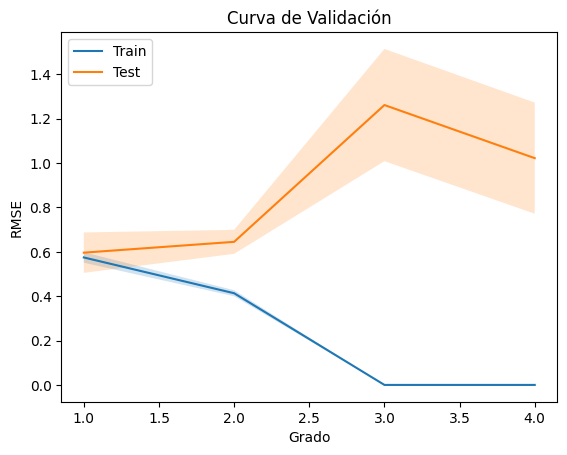

In [102]:
grados = [1, 2, 3, 4]

train_scores, test_scores = validation_curve(
    pipeline_poly,              
    X_train,
    y_train,
    param_name="poly__degree",
    param_range=grados,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()

plt.plot(grados, train_mean, label="Train")
plt.fill_between(grados,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.plot(grados, test_mean, label="Test")
plt.fill_between(grados,
                 test_mean - test_std,
                 test_mean + test_std,
                 alpha=0.2)

plt.xlabel("Grado")
plt.ylabel("RMSE")
plt.title("Curva de Validación")
plt.legend()
plt.show()



Al analizar la grafica vemos que desde 3 grados en el set de prueba el RMSE empieza a crecer bastante en comparacion con 2 grados, ademas vemos que en el set de entrenamiento el RMSE se vuelve 0 desde 3 grados lo que indica que desde este punto existe sobreajuste ya que representa perfectamente el set de entrenamiento y de cierta manere "memoriza" como se comportan los datos no predice el comportamiento, por esto mismo es que se ve el aumento en RMSE, el modelo ya no predice sino que ajusta a la memorizacion que tiene. Tambien vemos que tiene mejor RMSE en grado 1 por lo que si es un indicio de que es mejor regresion lineal a polinomial en este caso.

Con esto hecho procedemos a probar el modelo con Ridge para analizar que cambios produce este metodo, vamos a probar con alphas =  [0.0001, 0.001, 0.01, 0.1, 1, 10, 100] para ver en extremos como se comporta el modelo y ver cual es el mejor valor

In [103]:
pipe_ridge = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid_ridge = {
    "preprocessor__num__scaler": [StandardScaler(), RobustScaler()],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
print("Mejor alpha Ridge:", grid_ridge.best_params_)

y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R2:", r2_ridge)


Mejor alpha Ridge: {'model__alpha': 1, 'preprocessor__num__scaler': StandardScaler()}
RMSE: 0.5178336334856409
MAE: 0.1973707958158292
R2: 0.9603346274989142


Al terminar el modelo con Ridge podemos ver que el mejor alpha es 1, nuevamente vemos un R2 de 0.96 pero observamos que el RMSE y MAE es mayor que en la regresion polinomial por lo que sigue siendo mejor esta misma.

Vamos a proceder con el modelo de Lasso con los mimso alphas de Ridge y volver a hacer la comparacion.

In [104]:
pipe_lasso = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])
param_grid_lasso = {
    "preprocessor__num__scaler": [StandardScaler(), RobustScaler()],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
print("Mejor alpha Lasso:", grid_lasso.best_params_)

y_pred_lasso = best_lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("RMSE:", rmse_lasso)
print("MAE:", mae_lasso)
print("R2:", r2_lasso)


Mejor alpha Lasso: {'model__alpha': 0.01, 'preprocessor__num__scaler': StandardScaler()}
RMSE: 0.5186149418542252
MAE: 0.20147802499408785
R2: 0.960214842822804


In [105]:
coef_lasso = best_lasso.named_steps["model"].coef_
feature_names = best_lasso.named_steps["preprocessor"].get_feature_names_out()
pd.Series(coef_lasso, index=feature_names)

num__Age                                 0.002633
num__Abdominal Circumference (cm)        0.055018
num__Systolic BP                         1.065867
num__Diastolic BP                        0.014576
num__Total Cholesterol (mg/dL)           1.071932
num__HDL (mg/dL)                         0.009665
num__Fasting Blood Sugar (mg/dL)         0.019797
num__BMI                                 1.375013
cat__Sex_M                               0.000000
cat__Smoking Status_Y                    0.000000
cat__Diabetes Status_Y                   2.001201
cat__Physical Activity Level_High        0.000000
cat__Physical Activity Level_Low         0.000000
cat__Physical Activity Level_Moderate   -0.000000
cat__Family History of CVD_Y            -0.000000
dtype: float64

En el caso de Lasso vemos lo mismo que paso con Ridge, un R2 de 0.96 y mayores valores de RMSE y MAE pero en este caso vemos que las variables Smoking_Status, Sex_M, las Activity_Level y Family_History_of_CVD no se les da relevancia en el calculo de CVD risk score, tienen un coeficiente de 0. Se le da mayor importancia a diabetes, BMI, colesterol y presion sistolica lo cual tiene sentido ya que medicamente estas son las mediciones que mas afectan el CVD.

Ahora vamos a hacer el modelo combinado polinomial con Ridge y analizar.

In [112]:
pipe_poly_ridge = Pipeline([
    ("dropper", drop_columns_tr),
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_grid_poli_ridge = {
    "preprocessor__num__scaler": [StandardScaler(), RobustScaler()],
    "poly__degree": [2, 3, 4],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

grid_poli_ridge = GridSearchCV(
    pipe_poly_ridge,
    param_grid=param_grid_poli_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_poli_ridge.fit(X_train, y_train)

best_poli_ridge = grid_poli_ridge.best_estimator_

print("Mejores parámetros:", grid_poli_ridge.best_params_)


Mejores parámetros: {'model__alpha': 1, 'poly__degree': 3, 'preprocessor__num__scaler': RobustScaler()}


In [113]:
results = pd.DataFrame({
    "Modelo": ["Polinomial", "Ridge", "Lasso", "Poli+Ridge"],
    "RMSE": [rmse_poly, rmse_ridge, rmse_lasso, 
             np.sqrt(mean_squared_error(y_test, best_poli_ridge.predict(X_test)))],
    "MAE": [mae_poly, mae_ridge, mae_lasso,
            mean_absolute_error(y_test, best_poli_ridge.predict(X_test))],
    "R2": [r2_poly, r2_ridge, r2_lasso,
           r2_score(y_test, best_poli_ridge.predict(X_test))]
})
print(results)

       Modelo      RMSE       MAE        R2
0  Polinomial  0.501973  0.314256  0.962727
1       Ridge  0.517834  0.197371  0.960335
2       Lasso  0.518615  0.201478  0.960215
3  Poli+Ridge  0.598847  0.371695  0.946953


Media del RMSE 0.5935818065260449
Intervalo de confianza del RMSE (95%): [0.4529 a 0.7417]


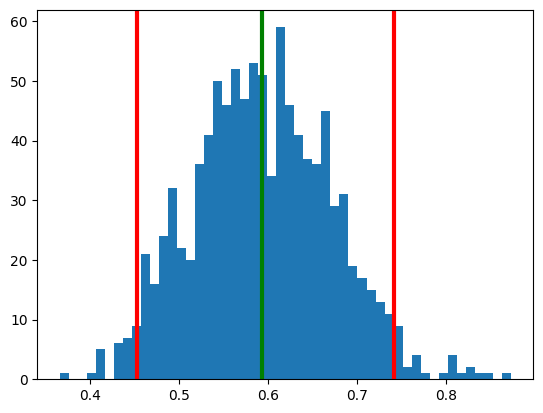

In [118]:
from sklearn.utils import resample

stats = []

for i in range(1000):
    X_res, y_res = resample(X_test, y_test, replace=True, n_samples=len(X_test))
    y_pred_res = best_poli_ridge.predict(X_res)
    stats.append(np.sqrt(mean_squared_error(y_res, y_pred_res)))

p_lower = np.percentile(stats, 2.5)
p_upper = np.percentile(stats, 97.5)

print(f"Media del RMSE {np.mean(stats)}")
print(f"Intervalo de confianza del RMSE (95%): [{p_lower:.4f} a {p_upper:.4f}]")

plt.hist(stats, bins=50)
plt.axvline(p_lower, color='red', linewidth=3)
plt.axvline(np.mean(stats), color='green', linewidth=3)
plt.axvline(p_upper, color='red', linewidth=3)
plt.show()


In [116]:
print("CV RMSE Polinomial:", -grid.best_score_)
print("CV RMSE Ridge:", -grid_ridge.best_score_)
print("CV RMSE Lasso:", -grid_lasso.best_score_)
print("CV RMSE Poly+Ridge:", -grid_poli_ridge.best_score_)


CV RMSE Polinomial: 0.6451277905216658
CV RMSE Ridge: 0.5963110571572312
CV RMSE Lasso: 0.592185036805492
CV RMSE Poly+Ridge: 0.6192343940393765
